# Estimating Part-Worth Utilities from Conjoint Choice Data

## Scenario
You have choice-based conjoint survey data where customers selected their preferred
subscription bundle from three alternatives across multiple tasks.
Your task is to estimate **part-worth utilities** — the utility contribution of each
attribute level — and compute **attribute importance** to rank which attributes most
drive customer preference.

## Your task
You will produce:
1. A fitted choice model with part-worth utilities for each attribute level
2. An attribute importance table (range-scaled by attribute)
3. A horizontal bar chart of attribute importance (sorted descending)
4. A short written answer: which attribute matters most, and what does that imply?

## Requirements
- Use `choice_conjoint_tasks.csv`
- Treat `price_usd`, `storage_gb`, `family_seats` as continuous
- Encode `support`, `ads`, `offline_download` as dummies with explicit reference levels
  (reference: `support_Standard`, `ads_Ads`, `offline_download_No`)
- Attribute importance = absolute value of coefficient × feature range (for continuous)
  or absolute value of coefficient (for binary/dummy features)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from pathlib import Path
PROJECT_DIR = Path(r"/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project")
DATA_DIR = PROJECT_DIR / "Project_Data"
if not DATA_DIR.exists():
    DATA_DIR = Path("Project_Data")

CHOICE_PATH  = DATA_DIR / "choice_conjoint_tasks.csv"
BUNDLES_PATH = DATA_DIR / "candidate_bundles.csv"
ADOPT_PATH   = DATA_DIR / "observational_offer_adoption.csv"
SURVEY_PATH  = DATA_DIR / "survey_value_drivers.csv"
MMM_PATH     = DATA_DIR / "marketing_weekly_channels.csv"
print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Project/Project_Data


In [3]:
# ── Step 1: Load the data ──────────────────────────────────────────────────
df = pd.read_csv(CHOICE_PATH)
print(df.shape, df.columns.tolist())
df.head()

(24000, 11) ['respondent_id', 'segment_true', 'task_id', 'alternative', 'price_usd', 'storage_gb', 'support', 'ads', 'family_seats', 'offline_download', 'chosen']


,respondent_id,segment_true,task_id,alternative,price_usd,storage_gb,support,ads,family_seats,offline_download,chosen
0,1,PowerUser,1,A,8,50,Standard,Ads,1,Yes,0
1,1,PowerUser,1,B,12,200,Standard,NoAds,4,No,0
2,1,PowerUser,1,C,5,1000,Standard,Ads,4,No,1
3,1,PowerUser,2,A,5,200,Priority,Ads,1,No,0
4,1,PowerUser,2,B,5,200,Standard,NoAds,4,Yes,1


In [4]:
# ── Step 2: Encode attributes and build feature matrix ────────────────────
# Keep all dummy levels, then drop reference levels explicitly
df_enc = pd.get_dummies(df, columns=['support','ads','offline_download'], drop_first=False)
df_enc.drop(columns=['support_Standard','ads_Ads','offline_download_No'], inplace=True)

# Continuous attributes: price, storage, seats — Categorical: dummy flags
feat_cols = ['price_usd','storage_gb','family_seats',
             'support_Priority','ads_NoAds','offline_download_Yes']
X = df_enc[feat_cols].astype(float)
y = df_enc['chosen']

In [5]:
# ── Step 3: Fit the model and extract part-worth utilities ────────────────
# Logistic regression on choice data; coefficients = part-worth utilities
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X, y)
partworths = pd.Series(model.coef_[0], index=feat_cols)
print("Part-worth utilities:")
print(partworths.round(4))

Part-worth utilities:
price_usd              -0.3572
storage_gb              0.0024
family_seats            0.1571
support_Priority        0.4930
ads_NoAds               0.8188
offline_download_Yes    0.2913
dtype: float64


In [6]:
# ── Step 4: Compute attribute importance ──────────────────────────────────────
# Attribute importance = how much utility CAN VARY across the tested range of that attribute.
# For continuous attributes: |coefficient| × (max − min observed value)
# For binary/dummy attributes: |coefficient| (the full range is always 0→1)

importance = {
    'price_usd':       abs(partworths['price_usd'])           * (df['price_usd'].max() - df['price_usd'].min()),
    'storage_gb':      abs(partworths['storage_gb'])          * (df['storage_gb'].max() - df['storage_gb'].min()),
    'family_seats':    abs(partworths['family_seats'])        * (df['family_seats'].max() - df['family_seats'].min()),
    'support':         abs(partworths['support_Priority']),
    'ads':             abs(partworths['ads_NoAds']),
    'offline_download':abs(partworths['offline_download_Yes']),
}

importance_series = pd.Series(importance).sort_values()
print("Attribute Importance (higher = drives preference more across tested range):")
print(importance_series.round(4))
print()
# Interpretive note about storage_gb
print("⚠  Note: storage_gb importance is high because the tested range spans")
print(f"   {df['storage_gb'].min():.0f}–{df['storage_gb'].max():.0f} GB — a large absolute gap.")
print(f"   Its raw coefficient ({partworths['storage_gb']:.4f}) is tiny; a 1-GB change barely")
print("   matters, but a 950-GB change adds up. Compare this to ads_NoAds, which has")
print(f"   a much stronger raw coefficient ({partworths['ads_NoAds']:.4f}) over a binary 0→1 range.")
print("   For design decisions, use coefficient magnitude to assess per-unit impact,")
print("   and importance to understand which attributes span a strategically wide range.")


Attribute Importance (higher = drives preference more across tested range):
offline_download    0.2913
support             0.4930
family_seats        0.7856
ads                 0.8188
storage_gb          2.2400
price_usd           3.5720
dtype: float64

⚠  Note: storage_gb importance is high because the tested range spans
   50–1000 GB — a large absolute gap.
   Its raw coefficient (0.0024) is tiny; a 1-GB change barely
   matters, but a 950-GB change adds up. Compare this to ads_NoAds, which has
   a much stronger raw coefficient (0.8188) over a binary 0→1 range.
   For design decisions, use coefficient magnitude to assess per-unit impact,
   and importance to understand which attributes span a strategically wide range.


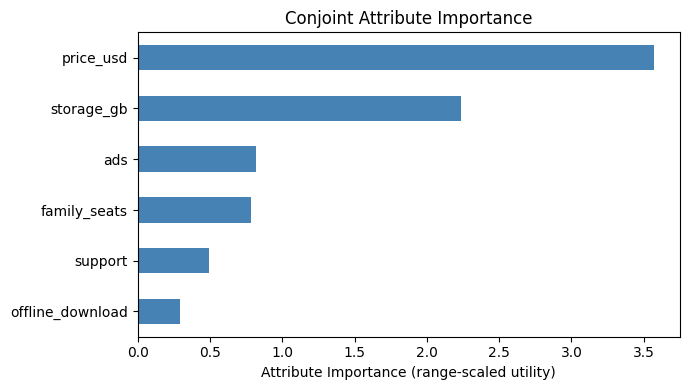

In [7]:
# ── Step 5: Plot attribute importance ─────────────────────────────────────
# Sorted bar chart; longer bar = attribute drives more utility variation
plt.figure(figsize=(7, 4))
importance_series.plot(kind='barh', color='steelblue')
plt.xlabel("Attribute Importance (range-scaled utility)")
plt.title("Conjoint Attribute Importance")
plt.tight_layout()
plt.show()

## Reflection

Answer the following in markdown:
1. Which attribute has the **highest importance score**, and what does that mean for product design?
2. Which attribute has the **lowest importance score**? What decision implication does that have?
3. Based on these results, if the product team could only improve **one** attribute for the new tier,
   which would you recommend and why?

In [8]:
# Print top and bottom importance for reference
top_attr = importance_series.idxmax()
bot_attr = importance_series.idxmin()
print(f"Highest importance: {top_attr} = {importance_series[top_attr]:.4f}")
print(f"Lowest importance:  {bot_attr} = {importance_series[bot_attr]:.4f}")
print()
print("Interpretation guide:")
print(f"  {top_attr}: customers vary most in utility when this attribute changes — prioritize it.")
print(f"  {bot_attr}: customers care least about variation here — lower design priority.")

Highest importance: price_usd = 3.5720
Lowest importance:  offline_download = 0.2913

Interpretation guide:
  price_usd: customers vary most in utility when this attribute changes — prioritize it.
  offline_download: customers care least about variation here — lower design priority.
